---
# Caricamento librerie di base e dataset
---

In [1]:
# Librerie fondamentali
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


# Caricare il dataset Iris
iris = load_iris()

X = iris.data
y = iris.target


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


---
# Naive Bayes e K-Nearest Neighbors
---

## Gaussian Naive Bayes

**Idea chiave:** Usa il teorema di Bayes assumendo che le features siano indipendenti tra loro (assunzione "naive").

**Quando usarlo:**
- Dataset con molte features
- Pochi dati di training
- Classificazione di testo
- Quando serve un baseline veloce

**Pro:** Velocissimo, funziona bene con pochi dati  
**Contro:** L'assunzione di indipendenza è spesso violata

In [2]:
# GaussianNB è semplicissimo: non ha quasi parametri!
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)

print(f"Accuracy Naive Bayes su Iris: {gnb.score(X_test, y_test):.2%}")

Accuracy Naive Bayes su Iris: 96.67%


In [5]:
# Naive Bayes può anche darci le probabilità di ogni classe
probabilities = gnb.predict_proba(X_test[:5])

print("Probabilità per i primi 5 campioni di test:")
print(pd.DataFrame(probabilities, columns=iris.target_names).round(3))

Probabilità per i primi 5 campioni di test:
   setosa  versicolor  virginica
0     1.0       0.000      0.000
1     0.0       0.088      0.912
2     0.0       1.000      0.000
3     0.0       1.000      0.000
4     1.0       0.000      0.000


## K-Nearest Neighbors (KNN)

**Idea chiave:** Per classificare un nuovo punto, guarda i K punti più vicini nel training set e assegna la classe più comune tra questi.

**Parametro principale:** `k` (n_neighbors) - quanti vicini considerare
- K piccolo (es. 1): molto sensibile al rumore
- K grande: decisioni più "smooth" ma può perdere dettagli

In [6]:
from sklearn.neighbors import KNeighborsClassifier

# KNN con k=5 (default)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

print(f"Accuracy KNN (k=5) su Iris: {knn.score(X_test, y_test):.2%}")

Accuracy KNN (k=5) su Iris: 100.00%


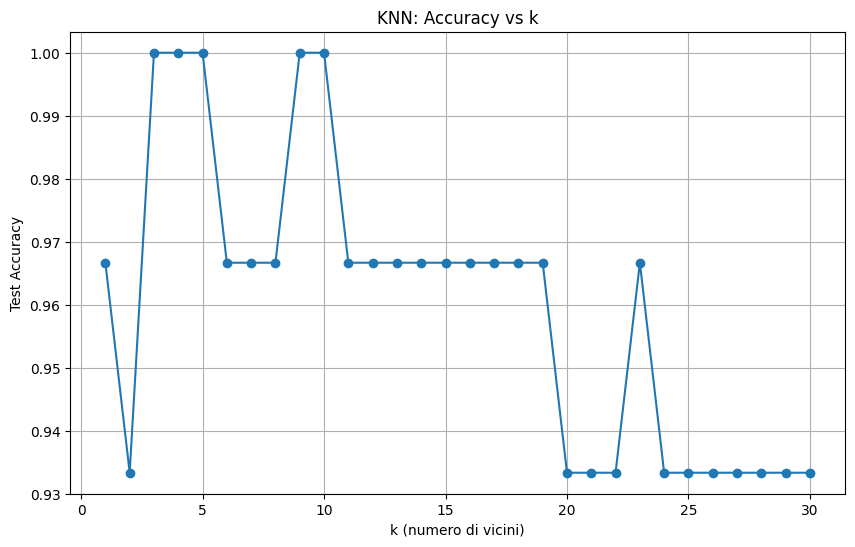

Migliore k: 3 (accuracy: 100.00%)


In [11]:
# Come varia l'accuracy al variare di k?
k_values = range(1, 31)
knn_scores = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    knn_scores.append(knn.score(X_test, y_test))
    
plt.figure(figsize=(10, 6))
plt.plot(k_values, knn_scores, 'o-')
plt.xlabel('k (numero di vicini)')
plt.ylabel('Test Accuracy')
plt.title('KNN: Accuracy vs k')
plt.grid(True)
plt.show()

best_k = k_values[np.argmax(knn_scores)]
print(f"Migliore k: {best_k} (accuracy: {max(knn_scores):.2%})")

## Confronto tra i tre algoritmi visti fin'ora

In [12]:
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score


# Definire i modelli
models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=3, random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN (k=5)': KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    # Misurare il tempo di training
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    # Misurare il tempo di predizione
    start = time.time()
    _ = model.predict(X_test)
    predict_time = time.time() - start
    
    # Cross-validation
    cv_scores = cross_val_score(model, X, y, cv=5)
    
    results.append({
        'Model': name,
        'CV Accuracy': f"{cv_scores.mean():.2%} ± {cv_scores.std():.2%}",
        'Train Time (ms)': f"{train_time*1000:.2f}",
        'Predict Time (ms)': f"{predict_time*1000:.2f}"
    })

pd.DataFrame(results)

,Model,CV Accuracy,Train Time (ms),Predict Time (ms)
0,Decision Tree,97.33% ± 2.49%,2.22,0.35
1,Naive Bayes,95.33% ± 2.67%,0.81,0.19
2,KNN (k=5),97.33% ± 2.49%,0.93,1.18


### Esercizio Confronto su dataset diversi

Confronta Decision Tree, Naive Bayes e KNN su **tre dataset diversi**:
1. Iris
2. Wine
3. Breast Cancer

Per ogni combinazione, calcola la CV accuracy. Quale algoritmo è migliore su quale dataset?


#### Suggerimento

```python
datasets = {
    'Iris': load_iris(),
    'Wine': load_wine(),
    'Breast Cancer': load_breast_cancer()
}

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=..., random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=...)
}

# Crea una tabella con i risultati
# ...
```

In [24]:
import pandas as pd

from sklearn.datasets import load_iris, load_wine, load_breast_cancer
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import cross_val_score

datasets = {
    'Iris': load_iris(),
    'Wine': load_wine(),
    'Breast Cancer': load_breast_cancer()
}

models = {
    'Decision Tree': DecisionTreeClassifier(max_depth=5, random_state=42),
    'Naive Bayes': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = []
for ds_name, ds in datasets.items():
    for model_name, model in models.items():
        scores = cross_val_score(model, ds.data, ds.target, cv=5)
        results.append({
            'Dataset': ds_name,
            'Model': model_name,
            'CV Accuracy': f"{scores.mean():.2%} ± {scores.std():.2%}"
        })

results_df = pd.DataFrame(results)
print(results_df)

print("\n\n")

print(results_df.pivot(index='Dataset', columns='Model', values='CV Accuracy'))

          Dataset          Model     CV Accuracy
0            Iris  Decision Tree  95.33% ± 3.40%
1            Iris    Naive Bayes  95.33% ± 2.67%
2            Iris            KNN  97.33% ± 2.49%
3            Iris  Random Forest  96.67% ± 2.11%
4            Wine  Decision Tree  86.54% ± 4.40%
5            Wine    Naive Bayes  96.63% ± 2.11%
6            Wine            KNN  69.13% ± 4.88%
7            Wine  Random Forest  97.21% ± 1.76%
8   Breast Cancer  Decision Tree  91.91% ± 1.80%
9   Breast Cancer    Naive Bayes  93.85% ± 1.46%
10  Breast Cancer            KNN  92.79% ± 2.18%
11  Breast Cancer  Random Forest  95.61% ± 2.28%



Model           Decision Tree             KNN     Naive Bayes   Random Forest
Dataset                                                                      
Breast Cancer  91.91% ± 1.80%  92.79% ± 2.18%  93.85% ± 1.46%  95.61% ± 2.28%
Iris           95.33% ± 3.40%  97.33% ± 2.49%  95.33% ± 2.67%  96.67% ± 2.11%
Wine           86.54% ± 4.40%  69.13% ± 4.88%  9